In [100]:
import sys

sys.path.insert(0, "..")

import pandas as pd
import seaborn as sns

sns.set_theme()
sns.set_color_codes()

from sktime.datasets import load_electric_devices_segmentation
from sktime.detection.clasp import ClaSPSegmentation, find_dominant_window_sizes
from sktime.detection.plotting.utils import (
    plot_time_series_with_change_points,
    plot_time_series_with_profiles,
)

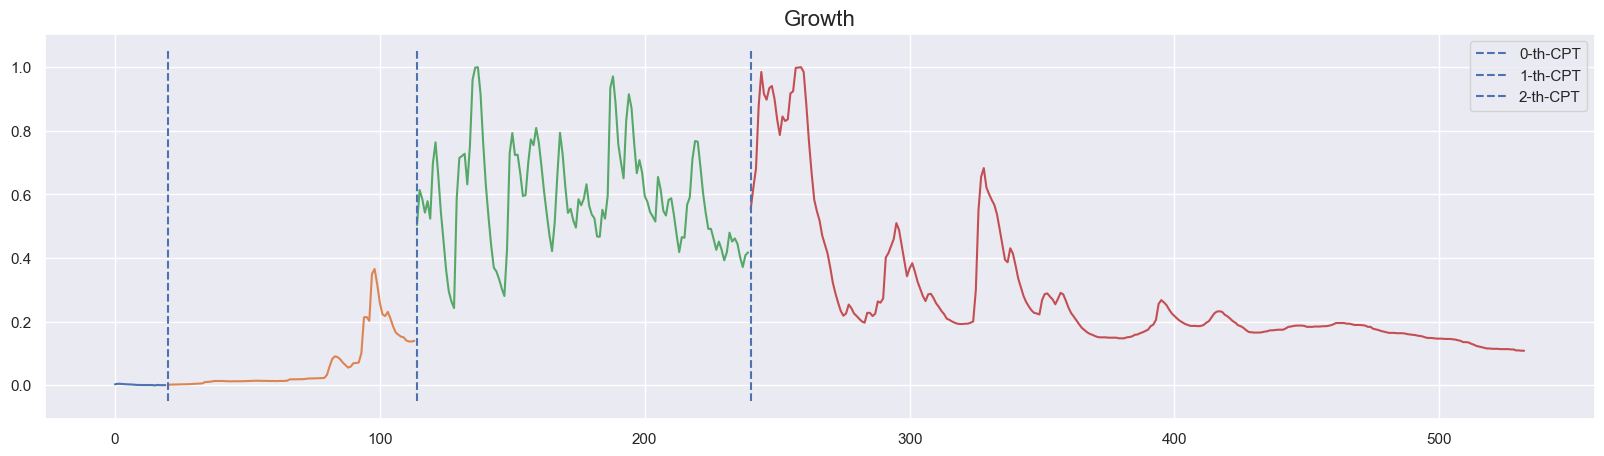

In [133]:
ts = pd.read_csv("./data/segmentation_03.csv")
ts = ts["co2_raw"]
# ts = ts["co2_raw"] - ts["co2_raw"].rolling(window=50, center=True).mean()
# ts.fillna(0, inplace=True)
# ts.reset_index(drop=True, inplace=True)

true_cps = [20, 114, 240]
_ = plot_time_series_with_change_points("Growth", ts, true_cps)

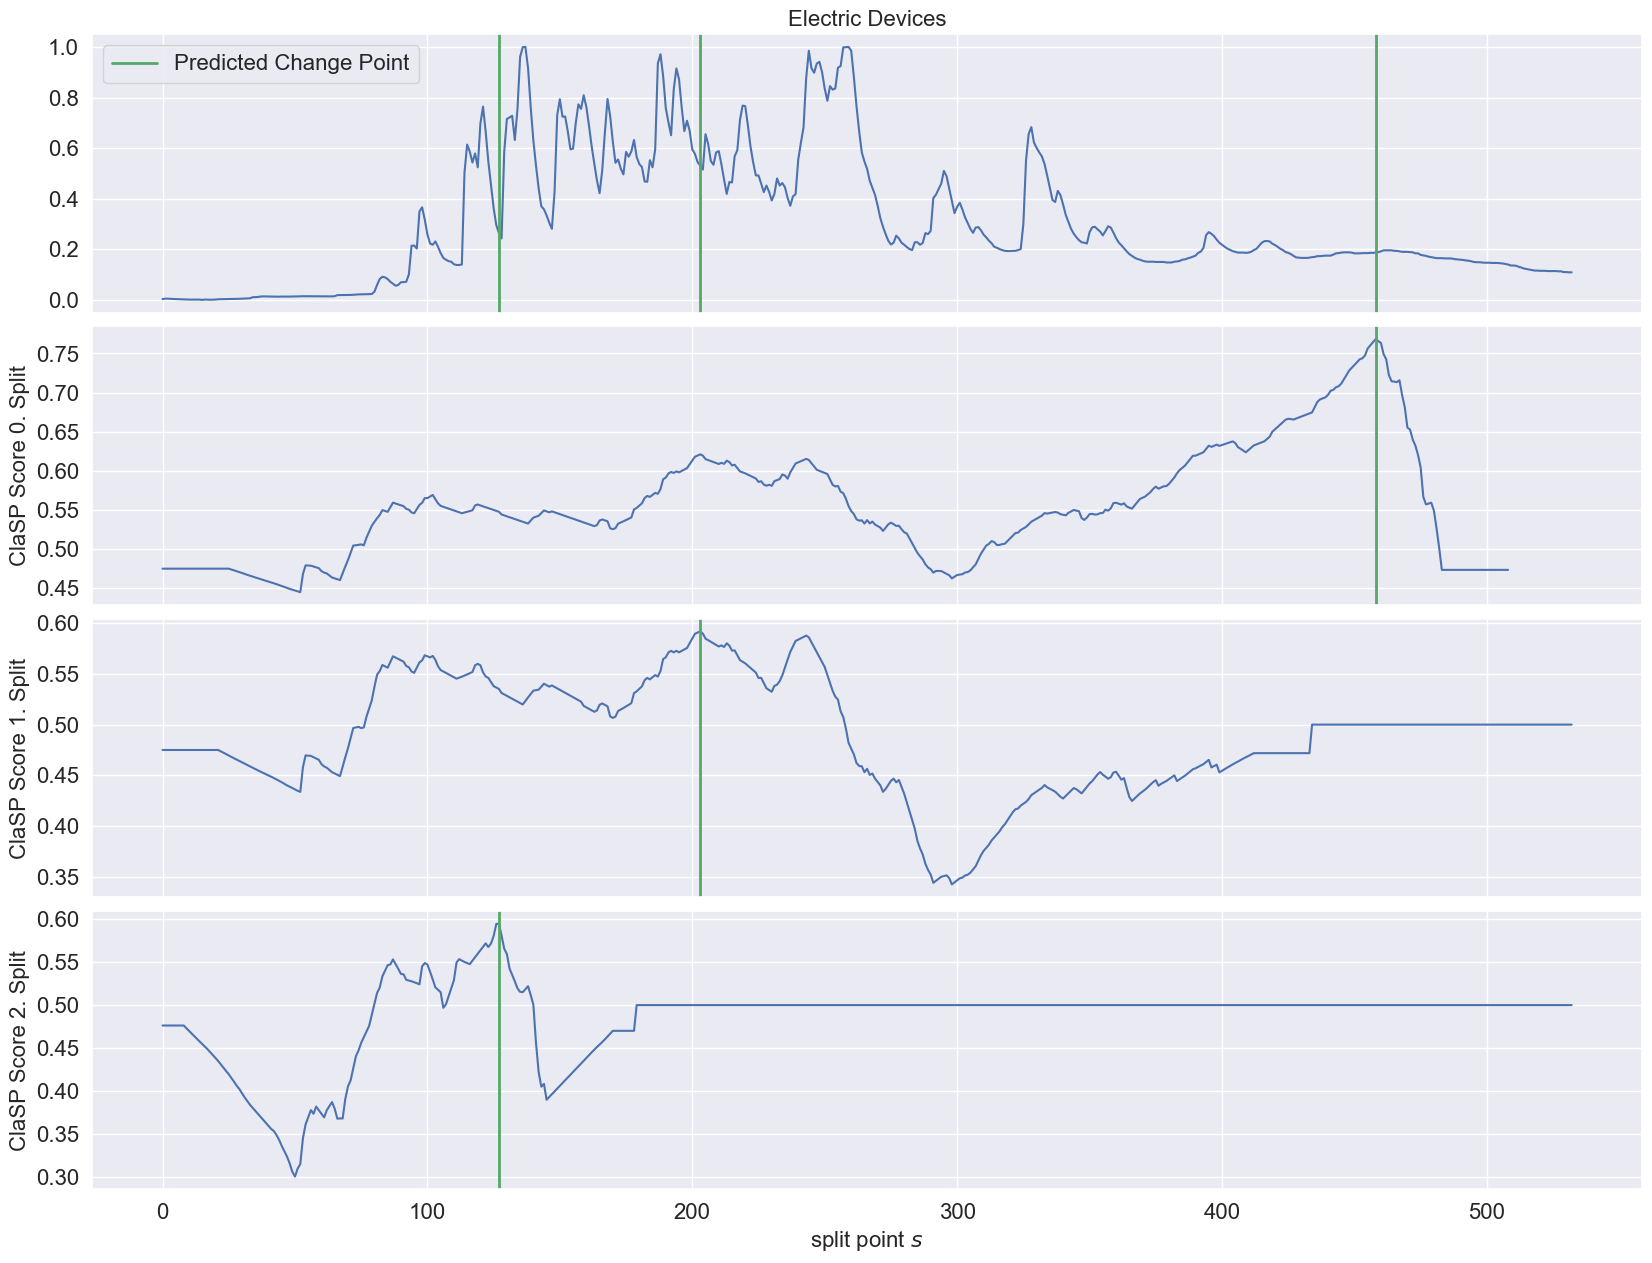

In [138]:
period_size = 25
clasp = ClaSPSegmentation(period_length=period_size, n_cps=3)
found_cps = clasp.fit_predict(ts)
profiles = clasp.profiles
scores = clasp.scores

_ = plot_time_series_with_profiles(
    "Electric Devices",
    ts,
    profiles,
    None,
    found_cps.to_numpy(),
)

# Output formats

ClaSP provides two different output formats that can be accessed using the 'sparse_to_dense' or 'dense_to_sparse' methods.

In [103]:
clasp = ClaSPSegmentation(period_length=period_size, n_cps=5)
found_segmentation = clasp.fit_predict(ts)
print(found_segmentation)

   ilocs
0      0


In [104]:
dense_segmentation = clasp.sparse_to_dense(y_sparse=found_segmentation, index=ts.index)
print(dense_segmentation[1035:1040])
print(dense_segmentation[4522:4527])
print(dense_segmentation[5716:5721])
print(dense_segmentation[7880:7885])

Series([], dtype: int64)
Series([], dtype: int64)
Series([], dtype: int64)
Series([], dtype: int64)


# ClaSP - Window Size Selection

ClaSP takes the window size 𝑤 as a hyper-parameter. This parameter has data-dependent effects on ClaSP's performance. When chosen too small, all windows tend to appear similar; when chosen too large, windows have a higher chance to overlap adjacent segments, blurring their discriminative power. 

A simple, yet effective method for choosing the window size is the dominant frequency of the Fourier Transform.

In [105]:
dominant_period_size = find_dominant_window_sizes(ts)
print("Dominant Period", dominant_period_size)

Dominant Period 10


Let us run ClaSP with the found dominant period length.

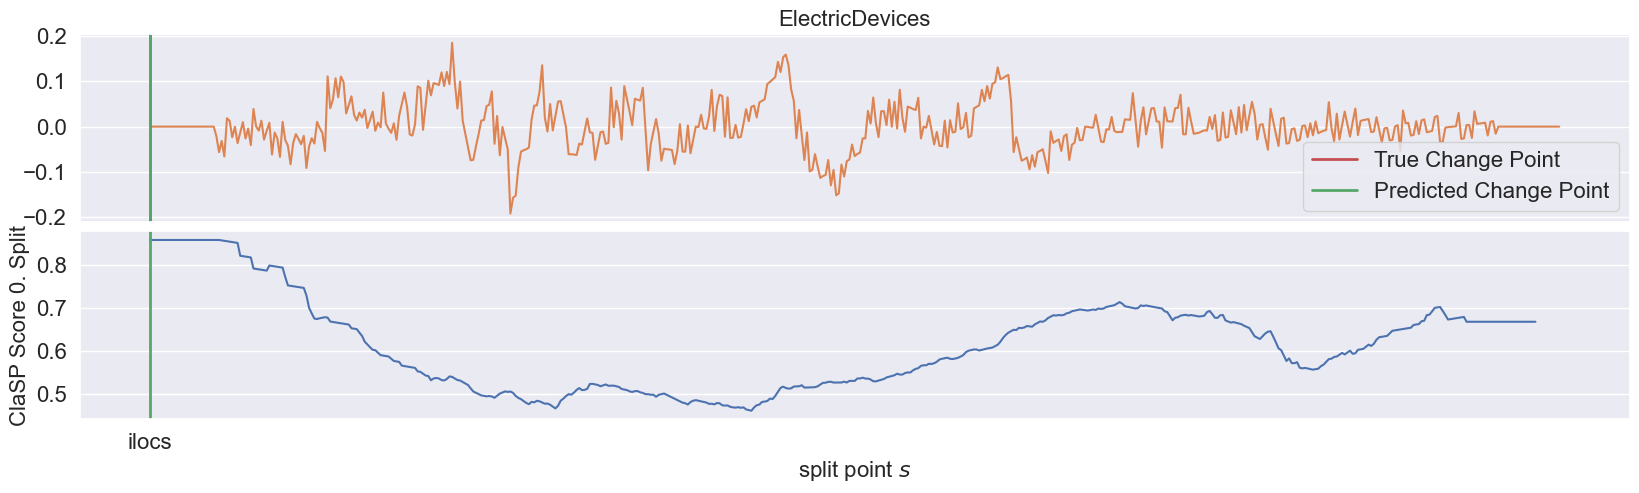

In [106]:
clasp = ClaSPSegmentation(period_length=dominant_period_size, n_cps=3)
found_cps = clasp.fit_predict(ts)
profiles = clasp.profiles
scores = clasp.scores

_ = plot_time_series_with_profiles(
    "ElectricDevices",
    ts,
    profiles,
    [0],
    found_cps,
)